# PR5 · Position Sizing: Kelly Criterion and Volatility Targeting

Knowing *what* to buy is half the problem. The other half is *how much*. This notebook covers the two most useful sizing rules: the Kelly criterion, which says how much leverage maximises long-run growth, and volatility targeting, which keeps risk steady over time.

## 1. Motivation

Suppose you have a real edge: a strategy that makes money on average. Bet too little and you leave growth on the table. Bet too much and a run of bad luck can wipe you out, even though every bet had a positive expected value. Many traders with good ideas went broke through sizing alone. How big should the bet be?

## 2. Intuition

**Kelly.** Imagine a coin that lands heads 60% of the time, paying even money. Betting everything on each flip has the highest *average* outcome, but you will eventually lose a flip and be left with nothing. Betting 1% each time is safe but grows painfully slowly. Somewhere in between is the bet size that makes your wealth grow fastest over many flips. For this coin it is 20% of your wealth per flip. That is the **Kelly bet**.

The key insight: growth depends on compounding, and losses hurt compounding more than gains help it (notebook 1: volatility drags down growth). Past a certain point, betting more *lowers* long-run growth, even though it raises the average return.

**Volatility targeting.** Markets swing between calm and turbulent periods (notebook 2). Holding a fixed position means your risk is low in calm times and very high in crises. Volatility targeting adjusts the position so that *risk* stays roughly constant: hold more when markets are calm, less when they are wild.

## 3. The math

**Kelly for a continuous return stream.** Put a fraction $f$ of capital into an asset with excess return mean $\mu$ and volatility $\sigma$ (the rest earns the risk-free rate). From notebook 1, long-run growth is the mean minus half the variance. For the leveraged position:
$$
g(f) = f\mu - \tfrac{1}{2} f^2\sigma^2 .
$$
Setting $g'(f) = \mu - f\sigma^2 = 0$ gives the **Kelly fraction**
$$
f^* = \frac{\mu}{\sigma^2},
$$
with maximum growth $g(f^*) = \dfrac{\mu^2}{2\sigma^2} = \dfrac{\text{SR}^2}{2}$.

Two useful facts follow from the parabola:
- **Half Kelly** ($f = f^*/2$) gives $g = \tfrac{3}{4}g(f^*)$: 75% of the growth with half the volatility.
- **Double Kelly** ($f = 2f^*$) gives $g = 0$: all that extra risk for *zero* growth. Beyond that, growth is negative.

**Volatility targeting.** Choose a target volatility $\sigma^{\text{target}}$ (e.g. 15%). Each day, estimate recent volatility $\hat\sigma_t$ from past returns and hold
$$
w_t = \min\!\left(\frac{\sigma^{\text{target}}}{\hat\sigma_t},\; w_{\max}\right),
$$
where $w_{\max}$ caps leverage. Using only *past* returns to compute $\hat\sigma_t$ keeps the rule free of look-ahead.

## 4. Code it

### 4.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

spy = prices["SPY"].pct_change()
rf = (prices["^IRX"].ffill() / 100 / 252).shift(1)
excess = (spy - rf).dropna()

### 4.2 The Kelly fraction for SPY

In [2]:
mu = excess.mean() * 252              # annual excess return
sigma2 = excess.var() * 252           # annual variance
f_star = mu / sigma2                  # Kelly fraction f* = mu / sigma^2
print(f"mu = {mu:.1%}, sigma = {np.sqrt(sigma2):.1%}, Sharpe = {mu / np.sqrt(sigma2):.2f}")
print(f"Kelly fraction f* = {f_star:.2f}  (i.e. {f_star:.1f}x leverage)")
print(f"Predicted max growth SR^2 / 2 = {mu**2 / sigma2 / 2:.1%} per year above the risk-free rate")

mu = 13.2%, sigma = 17.0%, Sharpe = 0.77
Kelly fraction f* = 4.53  (i.e. 4.5x leverage)
Predicted max growth SR^2 / 2 = 29.8% per year above the risk-free rate


Now we check the parabola against what actually happened. For each leverage level $f$, we hold $f$ times SPY (rebalanced daily) and compute the realised growth rate.

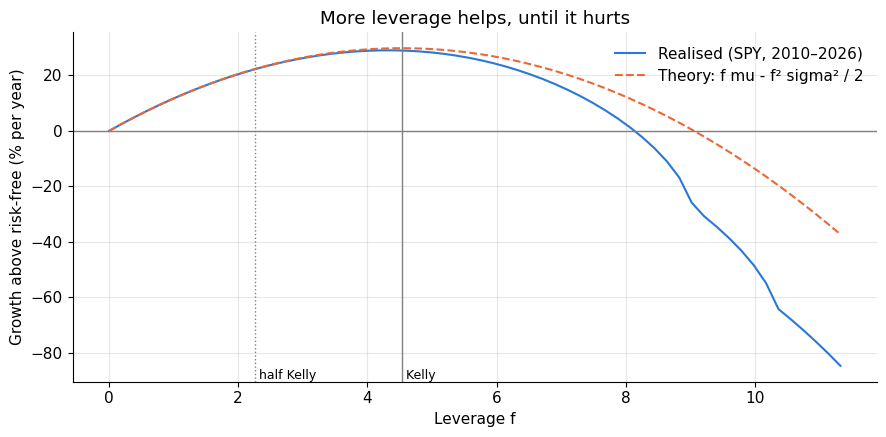

In [3]:
fs = np.linspace(0, 2.5 * f_star, 60)
realised = []
for f in fs:
    lev_returns = f * excess + rf.reindex(excess.index)     # f x excess + risk-free on all capital
    lev_returns = lev_returns.clip(lower=-0.99)             # cannot lose more than everything in a day
    growth = np.log1p(lev_returns).mean() * 252             # realised log growth per year
    realised.append(growth - rf.reindex(excess.index).mean() * 252)   # growth above risk-free
theory = fs * mu - 0.5 * fs**2 * sigma2                     # g(f) = f mu - f^2 sigma^2 / 2

fig, ax = plt.subplots()
ax.plot(fs, np.array(realised) * 100, label="Realised (SPY, 2010–2026)")
ax.plot(fs, theory * 100, "--", label="Theory: f mu - f² sigma² / 2")
ax.axvline(f_star, color="grey", linewidth=1)
ax.axvline(f_star / 2, color="grey", linewidth=1, ls=":")
ax.axhline(0, color="grey", linewidth=1)
ax.text(f_star, ax.get_ylim()[0], " Kelly", va="bottom", fontsize=9)
ax.text(f_star / 2, ax.get_ylim()[0], " half Kelly", va="bottom", fontsize=9)
ax.set_xlabel("Leverage f")
ax.set_ylabel("Growth above risk-free (% per year)")
ax.set_title("More leverage helps, until it hurts")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

- **The theory matches reality up to the Kelly point.** Both curves peak near $f^* \approx 4.5$, at about 29% a year above the risk-free rate.
- **Beyond Kelly, reality is worse than theory.** The theory assumes smooth, normally distributed returns. Real returns have fat tails: at 9× leverage, the March 2020 crash days alone take out a huge share of capital. Real double Kelly loses money, where the theory says growth is zero.
- **Half Kelly (dotted line) keeps about three quarters of the peak growth** at half the leverage and half the volatility.

And 4.5× leverage on the S&P 500 is not a sensible recommendation. It only looks optimal because we used the *realised* mean of a strong 16-year bull market. Section 4.3 shows how fragile that is.

### 4.3 The catch: Kelly needs $\mu$

$f^*$ is directly proportional to $\mu$, the hardest input to estimate (PR1). The standard error of the annual mean is $\sigma/\sqrt{Y}$.

In [4]:
years = len(excess) / 252
se_mu = np.sqrt(sigma2) / np.sqrt(years)      # standard error of the estimated annual mean
for label, m in [("mu - 2 SE", mu - 2 * se_mu), ("estimate", mu), ("mu + 2 SE", mu + 2 * se_mu)]:
    print(f"{label:>10}: mu = {m:6.1%} -> Kelly fraction {m / sigma2:5.2f}")

 mu - 2 SE: mu =   4.8% -> Kelly fraction  1.66
  estimate: mu =  13.2% -> Kelly fraction  4.53
 mu + 2 SE: mu =  21.5% -> Kelly fraction  7.40


With 16 years of data, the 95% range for $\mu$ is roughly 5%–21% a year. The Kelly fraction can therefore be anywhere from about 1.7× to 7.4×. If the true $\mu$ is at the low end and you bet 4.5×, you are close to triple Kelly, deep in the region where growth turns negative. This is why professionals use a fraction of Kelly (often a half or a quarter), or volatility targeting, which needs no estimate of $\mu$ at all.

### 4.4 Volatility targeting

In [5]:
target, w_max = 0.15, 2.0
sigma_hat = spy.rolling(63).std() * np.sqrt(252)            # recent vol, using past 63 days
weight = (target / sigma_hat).clip(upper=w_max).shift(1)     # decided yesterday, held today

vt = (weight * spy + (1 - weight) * rf).dropna()             # borrow/lend the rest at the risk-free rate
bh = spy.reindex(vt.index)
both = pd.DataFrame({"Vol-targeted SPY": vt, "Buy & hold SPY": bh})

value = (1 + both).cumprod()
ex = both.sub(rf.reindex(both.index), axis=0)
perf = pd.DataFrame({
    "CAGR": value.iloc[-1] ** (252 / len(both)) - 1,
    "Volatility": both.std() * np.sqrt(252),
    "Sharpe": np.sqrt(252) * ex.mean() / ex.std(),
    "Max drawdown": (value / value.cummax() - 1).min(),
    "Worst day": both.min(),
})
fmt = {"CAGR": "{:.1%}", "Volatility": "{:.1%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.1%}", "Worst day": "{:.1%}"}
perf.apply(lambda col: col.map(fmt[col.name].format))

,CAGR,Volatility,Sharpe,Max drawdown,Worst day
Vol-targeted SPY,12.7%,16.1%,0.73,-24.8%,-7.5%
Buy & hold SPY,13.9%,17.1%,0.76,-33.7%,-10.9%


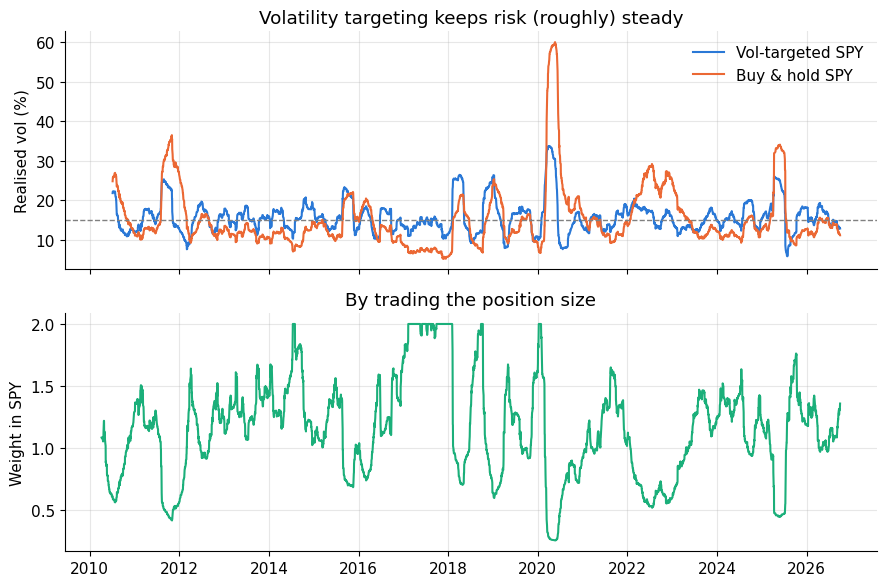

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
rolling_vol = both.rolling(63).std() * np.sqrt(252) * 100
for col in both:
    axes[0].plot(rolling_vol.index, rolling_vol[col], label=col)
axes[0].axhline(target * 100, color="grey", ls="--", linewidth=1)
axes[0].set_ylabel("Realised vol (%)")
axes[0].set_title("Volatility targeting keeps risk (roughly) steady")
axes[0].legend(frameon=False)
axes[1].plot(weight.index, weight, color=COLORS[2])
axes[1].set_ylabel("Weight in SPY")
axes[1].set_title("By trading the position size")
plt.tight_layout()
plt.show()

- **Risk is much more stable.** Buy-and-hold volatility swung from below 10% to 60% in 2020. The vol-targeted version mostly stays in the 10–25% band. When volatility jumped, the rule cut the position to about 0.3× SPY.
- **Tail risk is lower:** max drawdown −25% vs −34%, worst day −7.5% vs −11%.
- **The Sharpe ratio is about the same** (0.73 vs 0.76). Here, volatility targeting improved the *shape* of risk more than return per unit of risk.
- **It reacts with a lag.** In early 2018 the rule was at maximum leverage (2×) after a record-calm 2017, so a sudden volatility spike hit a large position (the blue bump in 2018). The cap $w_{\max}$ exists for exactly this reason.

## 5. Takeaways and where it breaks

- **There is an optimal bet size, and overbetting is worse than underbetting.** Growth falls fast past $f^*$ and is zero at $2f^*$.
- **Use a fraction of Kelly.** Because $\mu$ is uncertain, practitioners use half Kelly or less. It gives up a little growth for a lot of safety.
- **Volatility targeting is the practical cousin of Kelly.** It doesn't need $\mu$, only a volatility estimate, which is far more reliable.
- **Where it breaks:** Kelly assumes you know the return distribution and can rebalance continuously. Real returns have fat tails and gaps (a −20% overnight move can't be rebalanced away). Volatility targeting reacts with a lag, so it is still fully invested on the first days of a sudden crash.
- **Costs and leverage:** both methods trade more than buy-and-hold, and borrowing to lever up costs more than the T-bill rate used here.

**What you could build:** a sizing layer for the club's strategies: given any return stream, report its Kelly fraction with error bars, and run it at a volatility target with a leverage cap.